In [ ]:
## Load Dataset

We load the driver behavior dataset containing vehicle motion sensor data.

Each row represents a driving moment captured using sensors such as:

- acceleration (AccX, AccY, AccZ)
- gyroscope rotation (GyroX, GyroY, GyroZ)
- driving behavior class (target variable)

The dataset will be used to analyze driver behavior and predict driving risk.


In [2]:
# Import pandas for data handling and analysis
import pandas as pd

# Load dataset from local system
# The dataset contains vehicle sensor readings and driving behavior labels
df = pd.read_csv(r"C:\Users\Bittu\OneDrive\Documents\Driver Behavior Risk Prediction System\dataset_7M.csv")

# Display first 5 rows to inspect dataset structure
df.head()


,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,Class,Timestamp
0,0.036515,0.006347,0.005309,-0.601703,-0.500816,-0.013188,SLOW,2564982
1,0.037526,0.097570,-0.099660,-0.151070,4.619566,2.362678,NORMAL,955626
2,-0.017831,-0.000194,0.005489,0.631160,-0.452469,0.560772,SLOW,1928005
3,0.016611,-0.018242,-0.003205,0.690085,1.873017,7.267679,NORMAL,1779475
4,-0.007642,0.016439,0.018870,-0.502717,-0.572335,0.543868,SLOW,2228010


In [3]:
# Check dataset dimensions
# Returns (number of rows, number of columns)
df.shape

(7000000, 8)

In [5]:
# View all feature names in dataset
# Helps identify sensor variables and target variable
df.columns

Index(['AccX', 'AccY', 'AccZ', 'GyroX', 'GyroY', 'GyroZ', 'Class',
       'Timestamp'],
      dtype='str')

In [6]:
# Display dataset structure and data types
# Shows:
# - number of rows
# - column names
# - data types
# - memory usage
# - non-null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000000 entries, 0 to 6999999
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   AccX       float64
 1   AccY       float64
 2   AccZ       float64
 3   GyroX      float64
 4   GyroY      float64
 5   GyroZ      float64
 6   Class      str    
 7   Timestamp  int64  
dtypes: float64(6), int64(1), str(1)
memory usage: 427.2 MB


In [7]:
# Generate statistical summary of numerical columns
# Shows:
# - count
# - mean
# - standard deviation
# - min/max values
# - quartiles (25%, 50%, 75%)
df.describe()


,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,Timestamp
count,7.000000e+06,7.000000e+06,7.000000e+06,7.000000e+06,7.000000e+06,7.000000e+06,7.000000e+06
mean,9.041925e-05,-1.458442e-04,-1.016940e-04,7.741301e+00,7.748430e+00,7.752438e+00,1.750000e+06
std,1.060277e-01,1.058996e-01,7.176192e-02,8.411767e+00,8.456664e+00,8.467423e+00,1.010363e+06
min,-1.317100e+00,-1.171526e+00,-5.953476e-01,-1.565576e+01,-1.653618e+01,-1.624926e+01,0.000000e+00
25%,-2.892183e-02,-2.899777e-02,-2.797930e-02,1.249548e+00,1.242712e+00,1.245115e+00,8.749998e+05
50%,1.436165e-06,4.971914e-05,-6.613972e-05,5.257463e+00,5.249881e+00,5.250505e+00,1.750000e+06
75%,2.898459e-02,2.895441e-02,2.774794e-02,1.006754e+01,1.002500e+01,1.001642e+01,2.624999e+06
max,1.310304e+00,1.286458e+00,6.417587e-01,5.610947e+01,5.440130e+01,5.730567e+01,3.499999e+06


In [8]:
# Count number of samples for each driving behavior class
# This shows how many NORMAL, AGGRESSIVE, and SLOW driving instances exist
df["Class"].value_counts()


Class
NORMAL        3850000
AGGRESSIVE    1750000
SLOW          1400000
Name: count, dtype: int64

In [9]:
# Check number of missing values in each column
# Returns count of null values per feature
df.isnull().sum()


AccX         0
AccY         0
AccZ         0
GyroX        0
GyroY        0
GyroZ        0
Class        0
Timestamp    0
dtype: int64

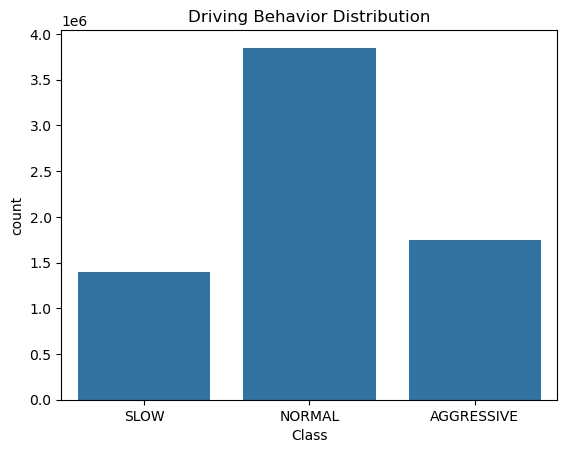

In [10]:
# Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Plot count of each driving behavior class
# Shows distribution of NORMAL, AGGRESSIVE, and SLOW driving
sns.countplot(x="Class", data=df)


# Add plot title
plt.title("Driving Behavior Distribution")


# Display plot
plt.show()


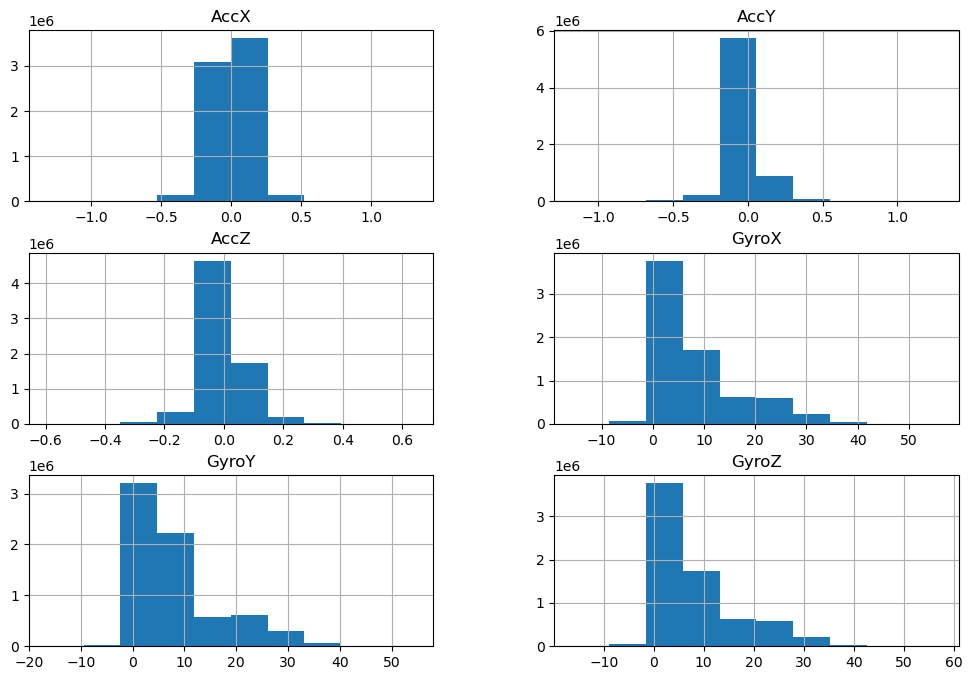

In [11]:
# Define sensor feature columns
# These represent vehicle motion and rotation measurements
sensor_cols = ["AccX","AccY","AccZ","GyroX","GyroY","GyroZ"]

# Plot histograms for each sensor feature
# Histograms show how values are distributed across dataset
# Helps detect data spread and unusual values
df[sensor_cols].hist(figsize=(12,8))

# Display plots
plt.show()


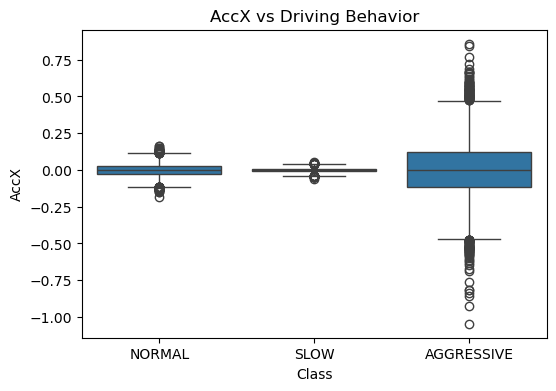

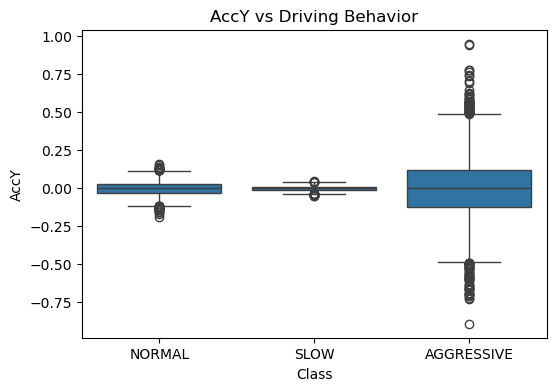

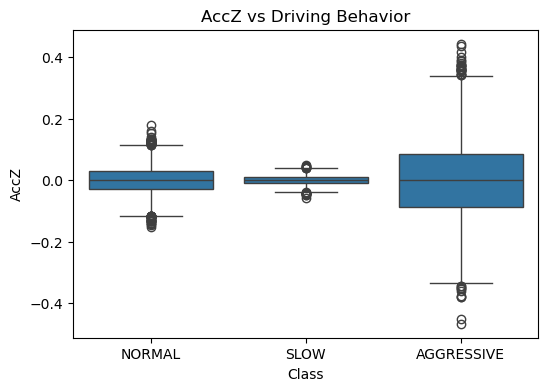

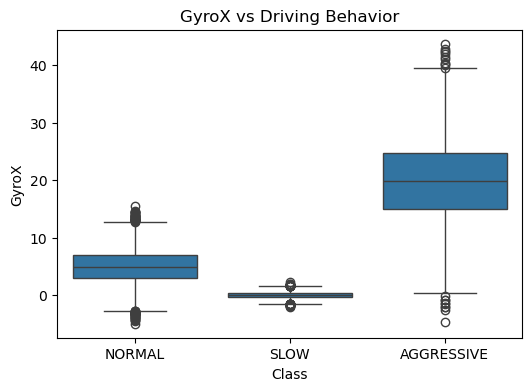

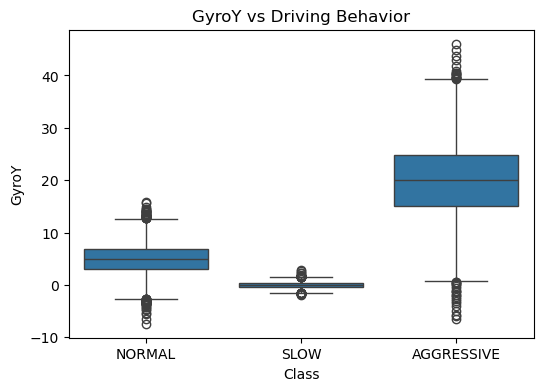

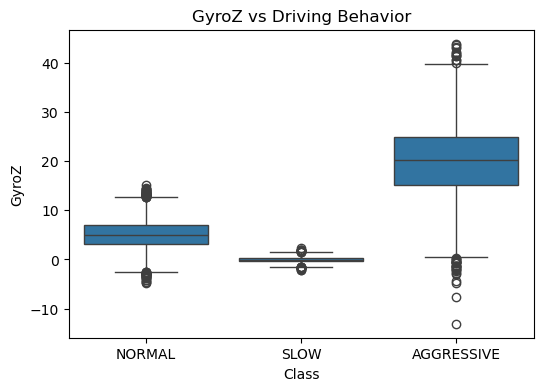

In [12]:
# Take random sample from dataset
# Sampling reduces computation time for large dataset (7 million rows)
sample_df = df.sample(20000)

# Compare sensor values across driving behavior classes
# Boxplots show:
# - median value
# - distribution spread
# - extreme values (outliers)
# - differences between driving types
for col in sensor_cols:

    # Create new figure for each sensor feature
    plt.figure(figsize=(6,4))

    # Plot sensor value vs driving behavior class
    sns.boxplot(x="Class", y=col, data=sample_df)

    # Add plot title
    plt.title(f"{col} vs Driving Behavior")

     # Display plot
    plt.show()


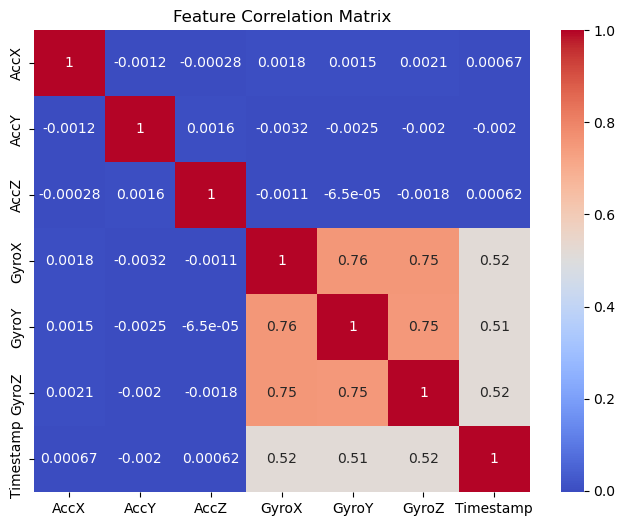

In [13]:
# Compute correlation matrix for numerical features
# We drop the target variable "Class" because correlation is calculated only for numeric data
corr = df.drop("Class", axis=1).corr()

# Create heatmap to visualize relationships between features
plt.figure(figsize=(8,6))

# Plot correlation matrix
# annot=True → show correlation values
# cmap="coolwarm" → color scale for positive/negative relationships
sns.heatmap(corr, annot=True, cmap="coolwarm")

# Add title
plt.title("Feature Correlation Matrix")

# Display plot
plt.show()


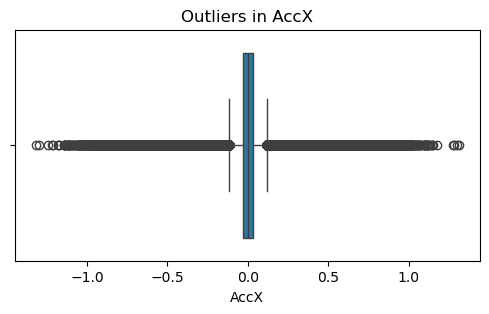

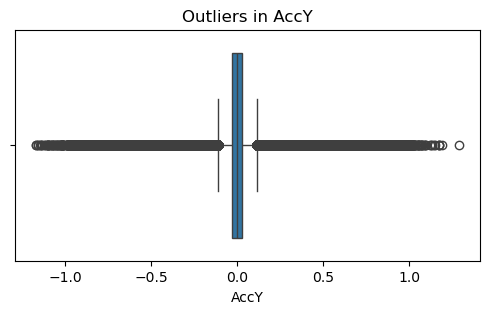

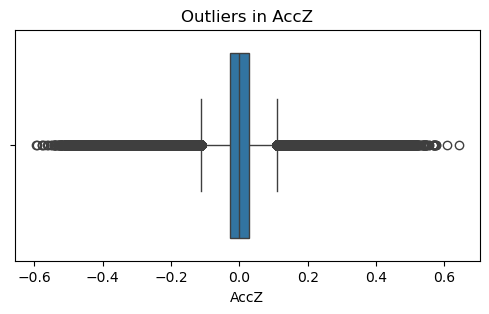

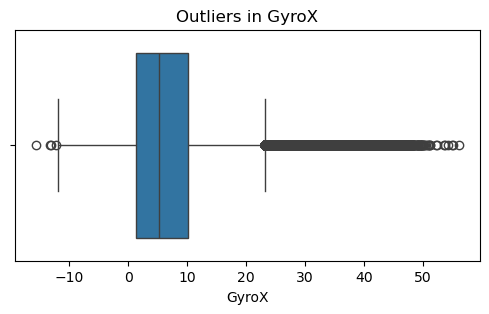

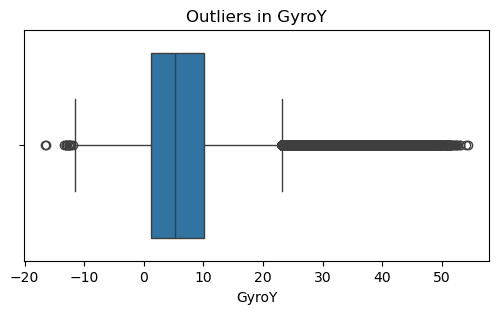

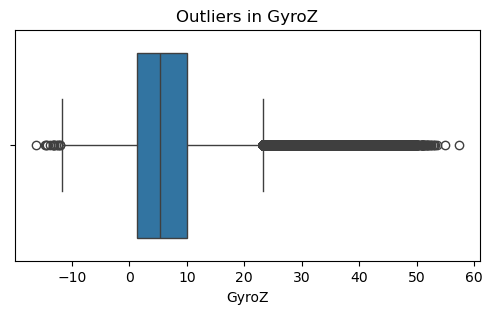

In [14]:
# Detect outliers in each sensor feature
# Boxplots show:
# - median value (center line)
# - interquartile range (box)
# - extreme values (points outside whiskers)
for col in sensor_cols:

    # Create figure for each feature
    plt.figure(figsize=(6,3))

     # Plot boxplot to detect extreme values
    sns.boxplot(x=df[col])

     # Add title
    plt.title(f"Outliers in {col}")

    # Display plot
    plt.show()


In [ ]:
# Phase 2 — Exploratory Data Analysis Summary

## Key Findings

- Dataset contains no missing values.
- Driving behavior classes are imbalanced.
- Sensor values show meaningful variation.
- Aggressive drivers show stronger motion patterns.
- Features have low correlation, providing unique information.
- Outliers represent extreme driving behavior.

## Conclusion
Sensor data contains strong signals for predicting driver behavior.
Dataset is suitable for machine learning modeling.


In [ ]:
#Phase 3 - Feature Engineering
## Feature Engineering — Motion Magnitude

We compute overall acceleration strength using acceleration sensors.

Motion magnitude represents total vehicle movement intensity,
which may indicate aggressive driving behavior.


In [15]:
import numpy as np

# Calculate overall acceleration magnitude
df["motion_magnitude"] = np.sqrt(
    df["AccX"]**2 + df["AccY"]**2 + df["AccZ"]**2
)

df[["motion_magnitude"]].head()


,motion_magnitude
0,0.037441
1,0.144430
2,0.018658
3,0.024878
4,0.026167


In [ ]:
## Feature Engineering — Rotation Magnitude

We compute total rotational movement using gyroscope sensors.
This represents turning intensity and steering behavior.


In [16]:
# Calculate total rotational movement
df["rotation_magnitude"] = np.sqrt(
    df["GyroX"]**2 + df["GyroY"]**2 + df["GyroZ"]**2
)

df[["rotation_magnitude"]].head()


,rotation_magnitude
0,0.782967
1,5.190901
2,0.957891
3,7.536814
4,0.935994


In [ ]:
## Feature Engineering — Driving Intensity Score

Driving intensity combines motion and rotation to measure
overall driving aggressiveness.


In [17]:
# Combine motion and rotation
df["driving_intensity"] = (
    df["motion_magnitude"] + df["rotation_magnitude"]
)

df[["driving_intensity"]].head()


,driving_intensity
0,0.820407
1,5.335332
2,0.976549
3,7.561693
4,0.962161


In [ ]:
## Feature Engineering — Harsh Braking Detection

Harsh braking is detected using strong negative acceleration values.
This may indicate unsafe driving behavior.


In [18]:
# threshold chosen based on data distribution
df["harsh_braking"] = (df["AccX"] < -0.3).astype(int)

df["harsh_braking"].value_counts()


harsh_braking
0    6886510
1     113490
Name: count, dtype: int64

In [ ]:
## Feature Engineering — Sharp Turning Detection

Sharp turning is detected using high rotational movement.
This indicates aggressive steering behavior.


In [19]:
# detect strong rotation
df["sharp_turning"] = (df["rotation_magnitude"] > 15).astype(int)

df["sharp_turning"].value_counts()


sharp_turning
0    5160579
1    1839421
Name: count, dtype: int64

In [20]:
df[[
    "motion_magnitude",
    "rotation_magnitude",
    "driving_intensity",
    "harsh_braking",
    "sharp_turning"
]].describe()


,motion_magnitude,rotation_magnitude,driving_intensity,harsh_braking,sharp_turning
count,7.000000e+06,7.000000e+06,7.000000e+06,7.000000e+06,7.000000e+06
mean,1.114893e-01,1.449260e+01,1.460409e+01,1.621286e-02,2.627744e-01
std,1.231931e-01,1.356469e+01,1.365782e+01,1.262933e-01,4.401410e-01
min,1.374825e-04,6.736588e-03,2.182912e-02,0.000000e+00,0.000000e+00
25%,3.563807e-02,5.997480e+00,6.065231e+00,0.000000e+00,0.000000e+00
50%,6.838654e-02,9.865998e+00,9.934150e+00,0.000000e+00,0.000000e+00
75%,1.205952e-01,1.757012e+01,1.769377e+01,0.000000e+00,1.000000e+00
max,1.600590e+00,7.315065e+01,7.373558e+01,1.000000e+00,1.000000e+00


In [ ]:

#Validate New Features vs Driving Behavior
## Feature Validation

We check whether engineered features differ across driving behaviors.
If features vary across classes, they are useful for prediction.
#Validate New Features vs Driving Behavior

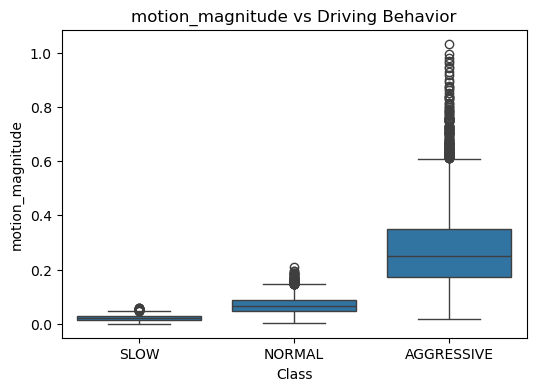

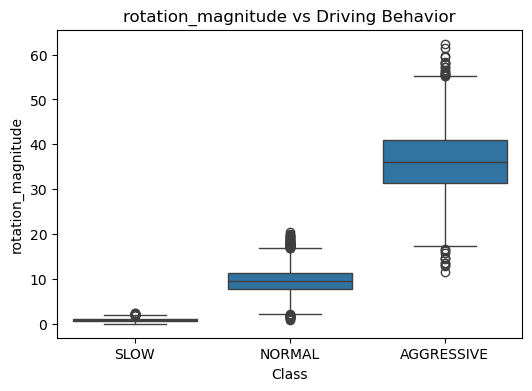

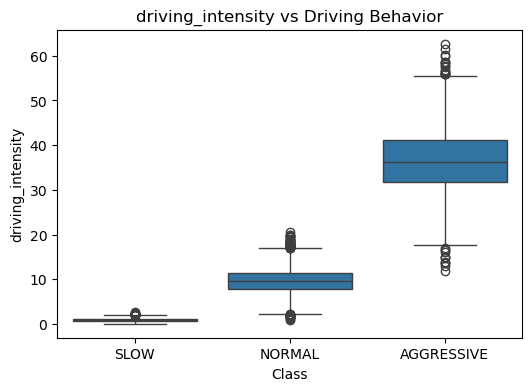

In [21]:
new_features = [
    "motion_magnitude",
    "rotation_magnitude",
    "driving_intensity"
]

sample_df = df.sample(20000)

for col in new_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Class", y=col, data=sample_df)
    plt.title(f"{col} vs Driving Behavior")
    plt.show()


In [ ]:
## Feature Selection

We select relevant features for training the machine learning model.


In [22]:
feature_cols = [
    "AccX","AccY","AccZ",
    "GyroX","GyroY","GyroZ",
    "motion_magnitude",
    "rotation_magnitude",
    "driving_intensity",
    "harsh_braking",
    "sharp_turning"
]

X = df[feature_cols]
y = df["Class"]

X.head()


,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,motion_magnitude,rotation_magnitude,driving_intensity,harsh_braking,sharp_turning
0,0.036515,0.006347,0.005309,-0.601703,-0.500816,-0.013188,0.037441,0.782967,0.820407,0,0
1,0.037526,0.097570,-0.099660,-0.151070,4.619566,2.362678,0.144430,5.190901,5.335332,0,0
2,-0.017831,-0.000194,0.005489,0.631160,-0.452469,0.560772,0.018658,0.957891,0.976549,0,0
3,0.016611,-0.018242,-0.003205,0.690085,1.873017,7.267679,0.024878,7.536814,7.561693,0,0
4,-0.007642,0.016439,0.018870,-0.502717,-0.572335,0.543868,0.026167,0.935994,0.962161,0,0


In [ ]:
## Target Encoding

We convert driving behavior labels into numerical values.
Machine learning models require numeric targets.


In [23]:
import sys
!{sys.executable} -m pip install scikit-learn


In [24]:
import sys
!{sys.executable} -m pip install --upgrade pip


In [25]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print(encoder.classes_)


['AGGRESSIVE' 'NORMAL' 'SLOW']


In [ ]:
## Train-Test Split

We split data into training and testing sets
to evaluate model performance.


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42
)

print(X_train.shape, X_test.shape)


(5600000, 11) (1400000, 11)


In [ ]:
## Feature Scaling

We standardize features so they have similar ranges.
This improves machine learning model performance.


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
#Phase 4
## Driver Behavior Classification — Logistic Regression

We train a logistic regression model to classify driver behavior.
This serves as a baseline model for comparison.


In [28]:
from sklearn.linear_model import LogisticRegression

# create model
log_model = LogisticRegression(max_iter=1000)

# train model
log_model.fit(X_train_scaled, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
## Model Prediction
We predict driving behavior on unseen test data.


In [29]:
y_pred_log = log_model.predict(X_test_scaled)


In [ ]:
## Model Evaluation
We evaluate model performance using classification metrics.


In [30]:
from sklearn.metrics import accuracy_score, classification_report

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))


Logistic Regression Accuracy: 0.99893

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    350635
           1       1.00      1.00      1.00    770109
           2       1.00      1.00      1.00    279256

    accuracy                           1.00   1400000
   macro avg       1.00      1.00      1.00   1400000
weighted avg       1.00      1.00      1.00   1400000



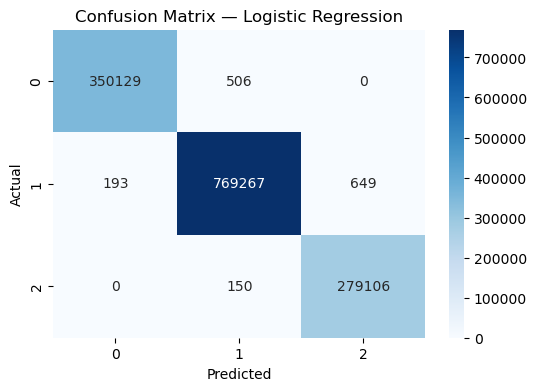

In [31]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
## Driver Behavior Classification — Random Forest

Random Forest captures nonlinear patterns in driving behavior.


In [32]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)


In [33]:
#Evaluate Random Forest
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.9990321428571428

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    350635
           1       1.00      1.00      1.00    770109
           2       1.00      1.00      1.00    279256

    accuracy                           1.00   1400000
   macro avg       1.00      1.00      1.00   1400000
weighted avg       1.00      1.00      1.00   1400000



In [34]:
# =============================
# Feature Importance
# =============================

import pandas as pd

importance = rf_model.feature_importances_

feature_names = X.columns

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feature_importance_df)


               Feature  Importance
8    driving_intensity    0.331292
7   rotation_magnitude    0.281786
3                GyroX    0.117477
10       sharp_turning    0.113030
4                GyroY    0.061196
5                GyroZ    0.058335
6     motion_magnitude    0.029729
1                 AccY    0.004143
0                 AccX    0.001581
2                 AccZ    0.001386
9        harsh_braking    0.000046


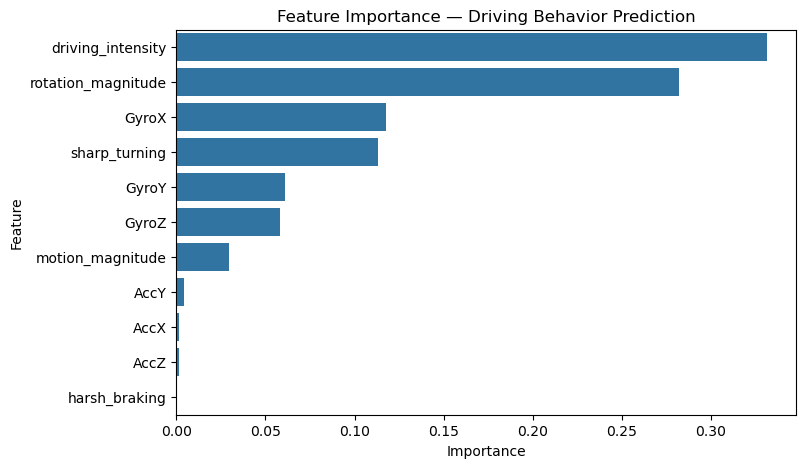

In [35]:
#Visualize Importance
plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df)
plt.title("Feature Importance — Driving Behavior Prediction")
plt.show()


In [37]:
# =============================
# Cross Validation (Using Sample → avoids memory error)
# =============================

from sklearn.model_selection import cross_val_score

# Use smaller dataset
X_sample = X_train_scaled[:100000]
y_sample = y_train[:100000]

scores = cross_val_score(
    rf_model,
    X_sample,
    y_sample,
    cv=3,   # reduce folds to save memory
    scoring="accuracy"
)

print("Cross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())


Cross Validation Scores: [0.99922002 0.99921999 0.99894999]
Average Accuracy: 0.9991299990998349


In [38]:
# =============================
# Cross Validation
# =============================

from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())


Cross Validation Scores: [0.99906429 0.99906161 0.99906518 0.99908036 0.99904554]
Average Accuracy: 0.9990633928571429


In [39]:
 #Phase 5 — Driver Risk Scoring System
# =============================
# Convert predictions back to original labels
# =============================

y_pred_labels = encoder.inverse_transform(y_pred_rf)

print(y_pred_labels[:10])


['NORMAL' 'AGGRESSIVE' 'AGGRESSIVE' 'NORMAL' 'NORMAL' 'SLOW' 'NORMAL'
 'AGGRESSIVE' 'SLOW' 'AGGRESSIVE']


In [41]:
# =============================
# Driver Risk Score Engine
# =============================

def calculate_risk_score(prediction):
    
    if prediction == "AGGRESSIVE":
        return 90   # high risk
    
    elif prediction == "NORMAL":
        return 50   # medium risk
    
    else:  # SLOW
        return 10   # low risk


In [42]:
# Generate risk scores
risk_scores = [calculate_risk_score(p) for p in y_pred_labels]

print(risk_scores[:10])


[50, 90, 90, 50, 50, 10, 50, 90, 10, 90]


In [43]:
# =============================
# Risk Category
# =============================

def risk_category(score):
    
    if score >= 80:
        return "HIGH RISK"
    
    elif score >= 40:
        return "MEDIUM RISK"
    
    else:
        return "LOW RISK"


risk_levels = [risk_category(s) for s in risk_scores]

print(risk_levels[:10])


['MEDIUM RISK', 'HIGH RISK', 'HIGH RISK', 'MEDIUM RISK', 'MEDIUM RISK', 'LOW RISK', 'MEDIUM RISK', 'HIGH RISK', 'LOW RISK', 'HIGH RISK']


In [44]:
# =============================
# Final Risk Output Table
# =============================

import pandas as pd

results_df = pd.DataFrame({
    "Actual Behavior": encoder.inverse_transform(y_test),
    "Predicted Behavior": y_pred_labels,
    "Risk Score": risk_scores,
    "Risk Level": risk_levels
})

results_df.head()


,Actual Behavior,Predicted Behavior,Risk Score,Risk Level
0,NORMAL,NORMAL,50,MEDIUM RISK
1,AGGRESSIVE,AGGRESSIVE,90,HIGH RISK
2,AGGRESSIVE,AGGRESSIVE,90,HIGH RISK
3,NORMAL,NORMAL,50,MEDIUM RISK
4,NORMAL,NORMAL,50,MEDIUM RISK


<Axes: title={'center': 'Driver Risk Distribution'}, xlabel='Risk Level'>

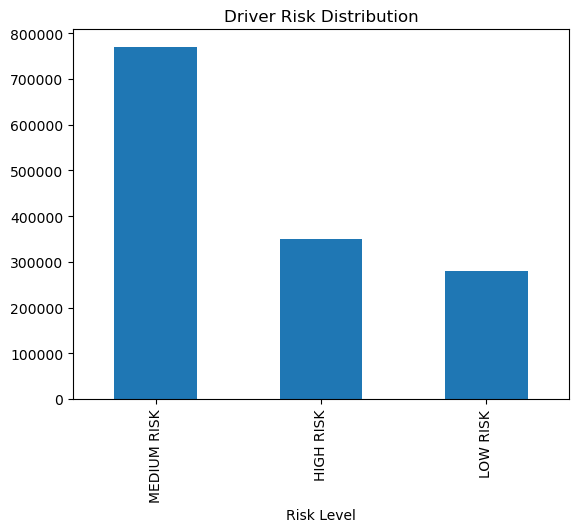

In [45]:
# Risk distribution
results_df["Risk Level"].value_counts().plot(kind="bar", title="Driver Risk Distribution")


In [53]:
#Phase 6 — Real-Time Driver Risk Prediction System
import joblib

# Save trained model
joblib.dump(rf_model, "driver_risk_model.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save label encoder
joblib.dump(encoder, "label_encoder.pkl")

print("Model, scaler, and encoder saved successfully")



Model, scaler, and encoder saved successfully


In [54]:
# Load saved model + scaler + encoder
model_loaded = joblib.load("driver_risk_model.pkl")
scaler_loaded = joblib.load("scaler.pkl")
encoder_loaded = joblib.load("label_encoder.pkl")

print("Model loaded successfully")


Model loaded successfully


In [55]:
import numpy as np
import pandas as pd

def predict_driver_risk(accx, accy, accz, gyrox, gyroy, gyroz):

    # Feature Engineering
    motion_magnitude = np.sqrt(accx**2 + accy**2 + accz**2)
    rotation_magnitude = np.sqrt(gyrox**2 + gyroy**2 + gyroz**2)
    driving_intensity = motion_magnitude + rotation_magnitude
    harsh_braking = 1 if accx < -0.5 else 0
    sharp_turning = 1 if abs(gyroz) > 20 else 0

    # Create dataframe (fix sklearn warning)
    columns = [
        "AccX","AccY","AccZ",
        "GyroX","GyroY","GyroZ",
        "motion_magnitude",
        "rotation_magnitude",
        "driving_intensity",
        "harsh_braking",
        "sharp_turning"
    ]

    features = pd.DataFrame([[
        accx, accy, accz,
        gyrox, gyroy, gyroz,
        motion_magnitude,
        rotation_magnitude,
        driving_intensity,
        harsh_braking,
        sharp_turning
    ]], columns=columns)

    # Scale
    features_scaled = scaler_loaded.transform(features)

    # Predict
    prediction = model_loaded.predict(features_scaled)[0]

    labels = {0:"AGGRESSIVE", 1:"NORMAL", 2:"SLOW"}
    behavior = labels[prediction]

    # Risk score
    if behavior == "AGGRESSIVE":
        score = 90
    elif behavior == "NORMAL":
        score = 50
    else:
        score = 20

    # Risk level
    if score > 70:
        level = "HIGH RISK"
    elif score > 40:
        level = "MEDIUM RISK"
    else:
        level = "LOW RISK"

    print("Driving Behavior:", behavior)
    print("Risk Score:", score)
    print("Risk Level:", level)


In [56]:
#Run test
predict_driver_risk(
    accx=0.5,
    accy=0.2,
    accz=0.1,
    gyrox=20,
    gyroy=15,
    gyroz=30
)


Driving Behavior: AGGRESSIVE
Risk Score: 90
Risk Level: HIGH RISK


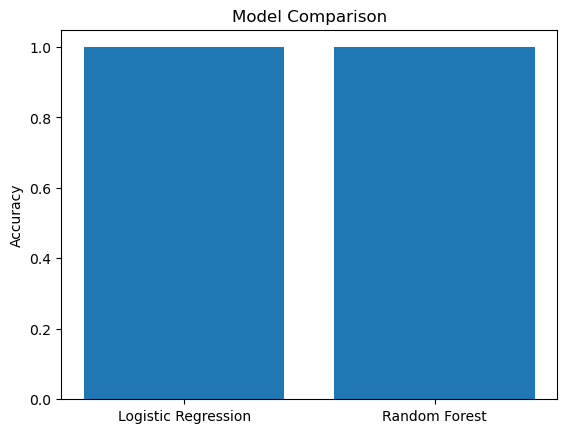

In [57]:
# ============================
# Phase 6 — Model Insights
# ============================
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Random Forest"]

accuracy = [
    accuracy_score(y_test, y_pred_log),
    accuracy_score(y_test, y_pred_rf)
]

plt.bar(models, accuracy)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()


<Axes: title={'center': 'Feature Importance'}>

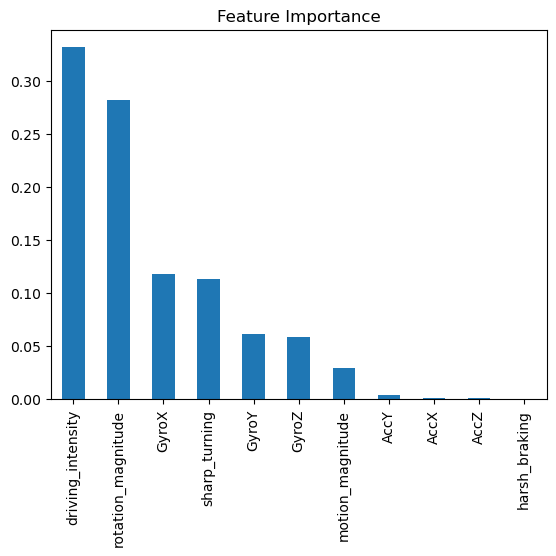

In [58]:
#Feature importance
import pandas as pd

importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance.plot(kind="bar", title="Feature Importance")
